# Volitility Clustering Lab - MNQ 1-Min Data (January)

**Question** Does high colatility on on bar tend to be followed by high volitility on the next bar (or several bars) in MNQ 1-minute futures data? 

**Why it matters:** This is the general form of my actual research question (does ATR(t) predict TR(t+1)?) - preacticing the full statistical pipeline here. 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

from lab.fvg_study import FairValueGapDetector
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv('../db/raw_parque/January_MNQ.csv')
fvg = FairValueGapDetector(candles = df, threshold = 100, time_frame = 5)
fvg.run_detector()

,high,high_ts,low,low_ts,type,spread
0,25644.50,2026-01-08 14:43:00,25675.50,2026-01-08 14:41:00,bearish,124.0
1,25622.50,2026-01-08 14:45:00,25652.75,2026-01-08 14:47:00,bullish,121.0
2,25641.00,2026-01-08 15:57:00,25675.00,2026-01-08 15:59:00,bullish,136.0
3,25685.50,2026-01-09 15:11:00,25722.00,2026-01-09 15:13:00,bullish,146.0
4,25792.00,2026-01-12 00:39:00,25833.25,2026-01-12 00:37:00,bearish,165.0
5,25750.75,2026-01-12 14:29:00,25783.25,2026-01-12 14:31:00,bullish,130.0
6,25912.50,2026-01-13 13:29:00,25993.50,2026-01-13 13:31:00,bullish,324.0
7,25696.50,2026-01-14 14:32:00,25744.75,2026-01-14 14:34:00,bullish,193.0
8,25713.75,2026-01-14 14:37:00,25746.75,2026-01-14 14:35:00,bearish,132.0
9,25563.00,2026-01-14 15:44:00,25593.75,2026-01-14 15:42:00,bearish,123.0


In [ ]:
df.describe()


,Unnamed: 0,contract_year,transactions,close,high,low,open,settlement_price,dollar_volume,volume
count,21143.000000,21143.0,21143.000000,21143.000000,21143.000000,21143.000000,21143.000000,0.0,2.114300e+04,21143.000000
mean,10571.000000,2026.0,683.968595,25736.082001,25740.436090,25731.587913,25736.078028,NaN,3.398687e+07,1322.101452
std,6103.602707,0.0,1035.116750,281.730243,281.253865,282.267675,281.732439,NaN,5.081803e+07,1978.350949
min,0.000000,2026.0,21.000000,25036.000000,25041.750000,25026.000000,25035.000000,NaN,6.237630e+05,24.000000
25%,5285.500000,2026.0,130.000000,25598.750000,25602.750000,25594.500000,25598.625000,NaN,6.386632e+06,248.000000
50%,10571.000000,2026.0,260.000000,25729.500000,25733.000000,25726.000000,25729.500000,NaN,1.309313e+07,510.000000
75%,15856.500000,2026.0,749.000000,25906.000000,25910.000000,25901.750000,25906.000000,NaN,3.757625e+07,1457.000000
max,21142.000000,2026.0,10260.000000,26342.000000,26349.000000,26337.750000,26341.750000,NaN,4.795455e+08,18604.000000


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 21143 entries, 0 to 21142
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        21143 non-null  int64  
 1   window_start      21143 non-null  str    
 2   timeframe         21143 non-null  str    
 3   ticker            21143 non-null  str    
 4   symbol            21143 non-null  str    
 5   contract_month    21143 non-null  str    
 6   contract_year     21143 non-null  int64  
 7   transactions      21143 non-null  int64  
 8   close             21143 non-null  float64
 9   high              21143 non-null  float64
 10  low               21143 non-null  float64
 11  open              21143 non-null  float64
 12  session_end_date  21143 non-null  str    
 13  settlement_price  0 non-null      float64
 14  dollar_volume     21143 non-null  int64  
 15  volume            21143 non-null  int64  
dtypes: float64(5), int64(5), str(6)
memory usage: 2.6 M

In [ ]:
df.isnull().sum()

Unnamed: 0              0
window_start            0
timeframe               0
ticker                  0
symbol                  0
contract_month          0
contract_year           0
transactions            0
close                   0
high                    0
low                     0
open                    0
session_end_date        0
settlement_price    21143
dollar_volume           0
volume                  0
dtype: int64

In [ ]:
df['window_start'] = pd.to_datetime(df['window_start'])
df = df.set_index('window_start')
df = df.sort_index()



In [ ]:
df.index

DatetimeIndex(['2026-01-08 11:38:00', '2026-01-08 11:39:00',
               '2026-01-08 11:40:00', '2026-01-08 11:41:00',
               '2026-01-08 11:42:00', '2026-01-08 11:43:00',
               '2026-01-08 11:44:00', '2026-01-08 11:45:00',
               '2026-01-08 11:46:00', '2026-01-08 11:47:00',
               ...
               '2026-01-29 23:51:00', '2026-01-29 23:52:00',
               '2026-01-29 23:53:00', '2026-01-29 23:54:00',
               '2026-01-29 23:55:00', '2026-01-29 23:56:00',
               '2026-01-29 23:57:00', '2026-01-29 23:58:00',
               '2026-01-29 23:59:00', '2026-01-30 00:00:00'],
              dtype='datetime64[us]', name='window_start', length=21143, freq=None)

In [ ]:
df.index = df.index.tz_localize('America/Chicago')

In [ ]:
gaps = df.index.to_series().diff()
gaps.value_counts().head(10)

window_start
0 days 00:01:00    21126
0 days 01:01:00       12
2 days 01:01:00        3
0 days 05:01:00        1
Name: count, dtype: int64

In [ ]:
gaps[gaps > pd.Timedelta(minutes=90)]

window_start
2026-01-11 23:00:00-06:00   2 days 01:01:00
2026-01-18 23:00:00-06:00   2 days 01:01:00
2026-01-19 23:00:00-06:00   0 days 05:01:00
2026-01-25 23:00:00-06:00   2 days 01:01:00
Name: window_start, dtype: timedelta64[us]

In [ ]:
prev_close = df['close'].shift(1)
range1 = df['high'] - df['low']
range2 = np.abs(df['high'] - prev_close )
range3 = np.abs(df['low'] - prev_close)

df['true_range'] = pd.concat([range1, range2, range3], axis=1).max(axis=1)

In [ ]:
df['true_range']

window_start
2026-01-08 11:38:00-06:00     5.00
2026-01-08 11:39:00-06:00    10.00
2026-01-08 11:40:00-06:00    10.00
2026-01-08 11:41:00-06:00     5.75
2026-01-08 11:42:00-06:00     3.75
                             ...  
2026-01-29 23:56:00-06:00    11.25
2026-01-29 23:57:00-06:00    15.00
2026-01-29 23:58:00-06:00    15.00
2026-01-29 23:59:00-06:00    10.75
2026-01-30 00:00:00-06:00    13.00
Name: true_range, Length: 21143, dtype: float64

In [ ]:
df = df.iloc[1:]

In [ ]:
df['true_range'].isnull().sum()

np.int64(0)

In [ ]:
df['log_return'] = np.log(df['close'] / df['close'].shift(1))

In [ ]:
df['log_return'].isnull().sum()

np.int64(1)

In [ ]:
df = df.iloc[1:]

In [ ]:
df.head(10)

,Unnamed: 0,timeframe,ticker,symbol,contract_month,contract_year,transactions,close,high,low,open,session_end_date,settlement_price,dollar_volume,volume,true_range,log_return
window_start,,,,,,,,,,,,,,,,,
2026-01-08 11:40:00-06:00,2,1min,MNQH6,MNQ,H,2026,222,25778.25,25780.75,25770.75,25771.75,2026-01-08,NaN,12449620,483,10.00,0.000252
2026-01-08 11:41:00-06:00,3,1min,MNQH6,MNQ,H,2026,147,25781.00,25782.00,25776.25,25778.00,2026-01-08,NaN,7991832,310,5.75,0.000107
2026-01-08 11:42:00-06:00,4,1min,MNQH6,MNQ,H,2026,93,25782.50,25782.75,25779.00,25781.25,2026-01-08,NaN,4821052,187,3.75,0.000058
2026-01-08 11:43:00-06:00,5,1min,MNQH6,MNQ,H,2026,96,25778.00,25783.00,25776.50,25783.00,2026-01-08,NaN,4717575,183,6.50,-0.000175
2026-01-08 11:44:00-06:00,6,1min,MNQH6,MNQ,H,2026,114,25774.75,25778.50,25773.25,25777.75,2026-01-08,NaN,6237596,242,5.25,-0.000126
2026-01-08 11:45:00-06:00,7,1min,MNQH6,MNQ,H,2026,129,25768.25,25775.00,25767.75,25774.25,2026-01-08,NaN,7551085,293,7.25,-0.000252
2026-01-08 11:46:00-06:00,8,1min,MNQH6,MNQ,H,2026,152,25773.25,25773.50,25767.75,25768.25,2026-01-08,NaN,8143298,316,5.75,0.000194
2026-01-08 11:47:00-06:00,9,1min,MNQH6,MNQ,H,2026,91,25776.25,25777.50,25772.50,25773.75,2026-01-08,NaN,4639503,180,5.00,0.000116
2026-01-08 11:48:00-06:00,10,1min,MNQH6,MNQ,H,2026,90,25774.25,25777.75,25772.75,25776.00,2026-01-08,NaN,5283951,205,5.00,-0.000078


In [ ]:
mean_ret = df['log_return'].mean()
median_ret = df['log_return'].median()
std_ret = df['log_return'].std()
skew_ret = stats.skew(df['log_return'])
kurt_ret = stats.kurtosis(df['log_return'])

print(f"Mean: {mean_ret:.8f}")
print(f"Median: {median_ret:.10f}")
print(f"Std Dev: {std_ret:.8f}")
print(f"Skew: {skew_ret:.4f}")
print(f"Excess Kurtosis: {kurt_ret:.4f}")

Mean: 0.00000036
Median: 0.0000000000
Std Dev: 0.00027521
Skew: -2.6291
Excess Kurtosis: 98.6361


In [ ]:

df['log_return'].sort_values(ascending=False).head(5)

window_start
2026-01-21 19:27:00-06:00    0.004218
2026-01-13 13:30:00-06:00    0.003525
2026-01-20 15:21:00-06:00    0.002530
2026-01-20 14:33:00-06:00    0.002492
2026-01-14 14:33:00-06:00    0.002158
Name: log_return, dtype: float64

In [ ]:
df['log_return'].sort_values().head(5)

window_start
2026-01-18 23:00:00-06:00   -0.008918
2026-01-25 23:00:00-06:00   -0.008064
2026-01-09 14:48:00-06:00   -0.002877
2026-01-28 21:00:00-06:00   -0.002719
2026-01-14 21:54:00-06:00   -0.002530
Name: log_return, dtype: float64

In [ ]:
gaps.loc[['2026-01-18 23:00:00-06:00', '2026-01-25 23:00:00-06:00']]

window_start
2026-01-18 23:00:00-06:00   2 days 01:01:00
2026-01-25 23:00:00-06:00   2 days 01:01:00
Name: window_start, dtype: timedelta64[us]

In [ ]:
valid_gap = pd.Timedelta(minutes=1)
bad_return_mask = gaps != valid_gap

In [ ]:
bad_return_mask.sum()

np.int64(17)

In [ ]:
gaps[bad_return_mask].index[0] in df.index

False

In [ ]:
gaps = df.index.to_series().diff()
bad_return_mask = gaps != pd.Timedelta(minutes=1)
bad_return_mask.sum()

np.int64(17)

In [ ]:
df[['close', 'true_range', 'log_return']].head(1)

,close,true_range,log_return
window_start,,,
2026-01-08 11:40:00-06:00,25778.25,10.0,0.000252


In [ ]:
bad_return_mask = (gaps != pd.Timedelta(minutes=1)) & (gaps.notna())
bad_return_mask.sum()

np.int64(16)

In [ ]:
df.loc[bad_return_mask, ['log_return', 'true_range']] = np.nan
mean_ret = df['log_return'].mean()
median_ret = df['log_return'].median()
std_ret = df['log_return'].std()
skew_ret = stats.skew(df['log_return'], nan_policy='omit')
kurt_ret = stats.kurtosis(df['log_return'], nan_policy='omit')

print(f"Mean: {mean_ret:.8f}")
print(f"Median: {median_ret:.10f}")
print(f"Std Dev: {std_ret:.8f}")
print(f"Skew: {skew_ret:.4f}")
print(f"Excess Kurtosis: {kurt_ret:.4f}")

Mean: 0.00000113
Median: 0.0000000000
Std Dev: 0.00026164
Skew: 0.2026
Excess Kurtosis: 14.6558


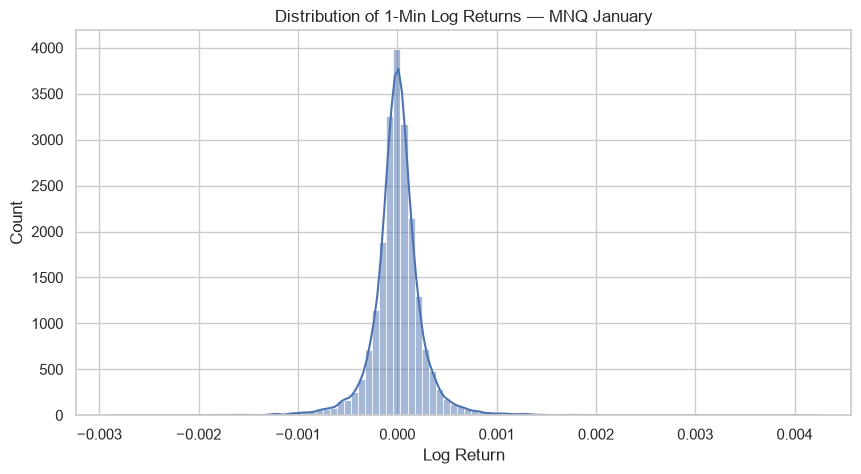

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['log_return'].dropna(), kde=True, bins=100)
plt.title("Distribution of 1-Min Log Returns — MNQ January")
plt.xlabel("Log Return")
plt.show()

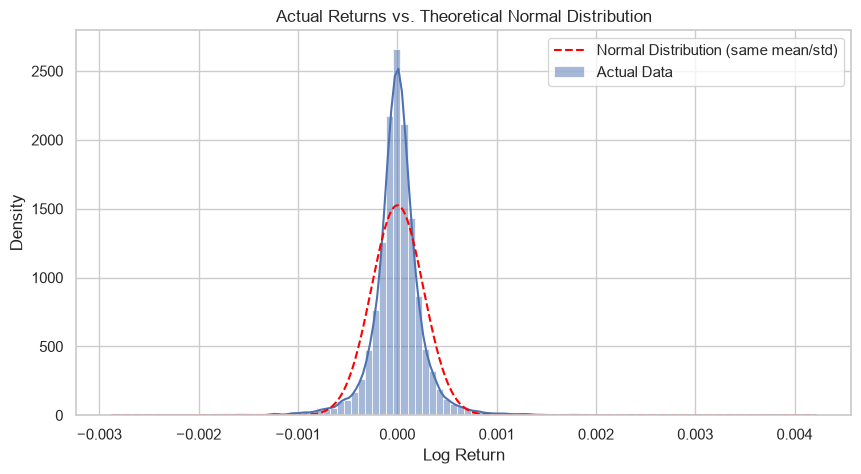

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df['log_return'].dropna(), kde=True, bins=100, stat='density', label='Actual Data')

x = np.linspace(df['log_return'].min(), df['log_return'].max(), 1000)
normal_curve = stats.norm.pdf(x, loc=mean_ret, scale=std_ret)
plt.plot(x, normal_curve, color='red', linestyle='--', label='Normal Distribution (same mean/std)')

plt.title("Actual Returns vs. Theoretical Normal Distribution")
plt.xlabel("Log Return")
plt.legend()
plt.show()

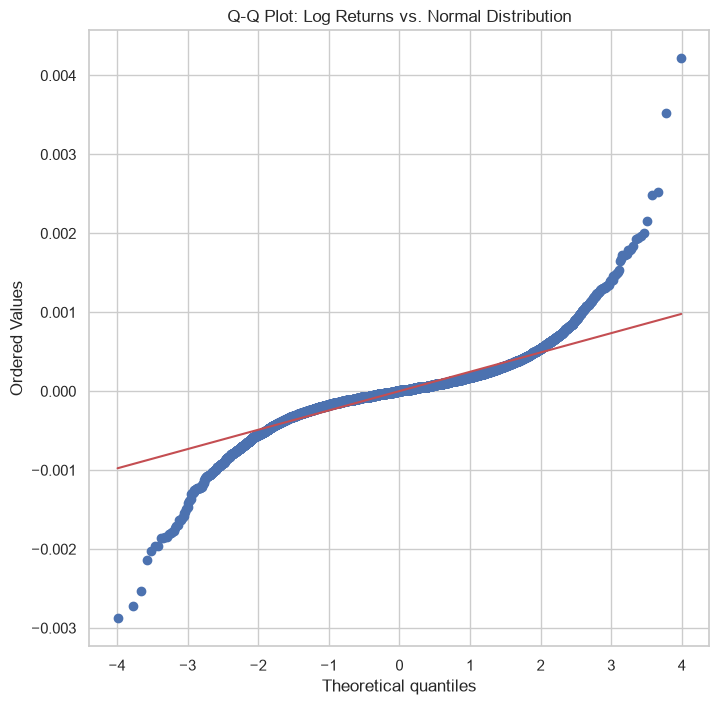

In [ ]:
plt.figure(figsize=(8, 8))
stats.probplot(df['log_return'].dropna(), dist="norm", plot=plt)
plt.title("Q-Q Plot: Log Returns vs. Normal Distribution")
plt.show()

In [ ]:
sample = df['log_return'].dropna().sample(5000, random_state=42)
stat, p_value = stats.shapiro(sample)

print(f"W statistic: {stat:.6f}")
print(f"p-value: {p_value}")


W statistic: 0.892116
p-value: 1.7016143622195036e-50


In [ ]:
clean_returns = df['log_return'].dropna()

norm_params = stats.norm.fit(clean_returns)

t_params = stats.t.fit(clean_returns)

print(f"Normal fit — mean: {norm_params[0]:.6f}, std: {norm_params[1]:.6f}")
print(f"t-dist fit — df: {t_params[0]:.2f}, loc: {t_params[1]:.6f}, scale: {t_params[2]:.6f}")

Normal fit — mean: 0.000001, std: 0.000262
t-dist fit — df: 1.99, loc: 0.000002, scale: 0.000132


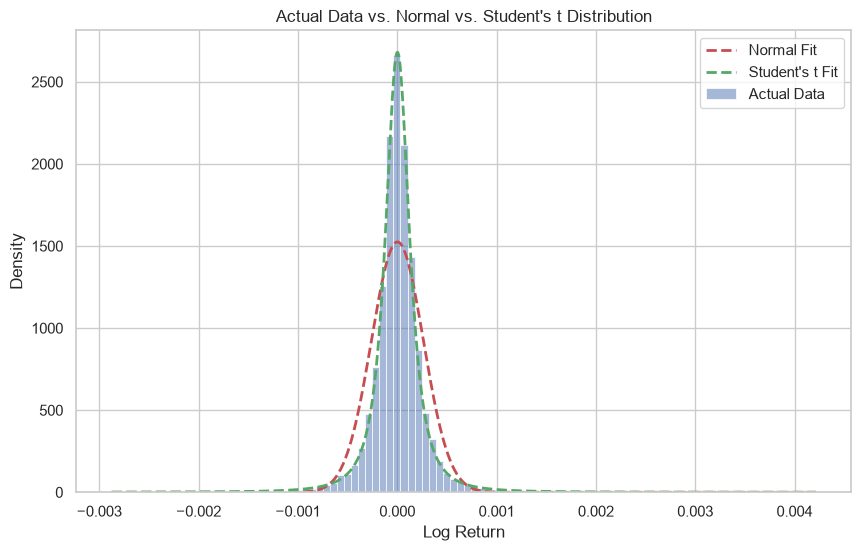

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(clean_returns, bins=100, stat='density', label='Actual Data', alpha=0.5)

x = np.linspace(clean_returns.min(), clean_returns.max(), 1000)
plt.plot(x, stats.norm.pdf(x, *norm_params), 'r--', label='Normal Fit', linewidth=2)
plt.plot(x, stats.t.pdf(x, *t_params), 'g--', label="Student's t Fit", linewidth=2)

plt.title("Actual Data vs. Normal vs. Student's t Distribution")
plt.xlabel("Log Return")
plt.legend()
plt.show()

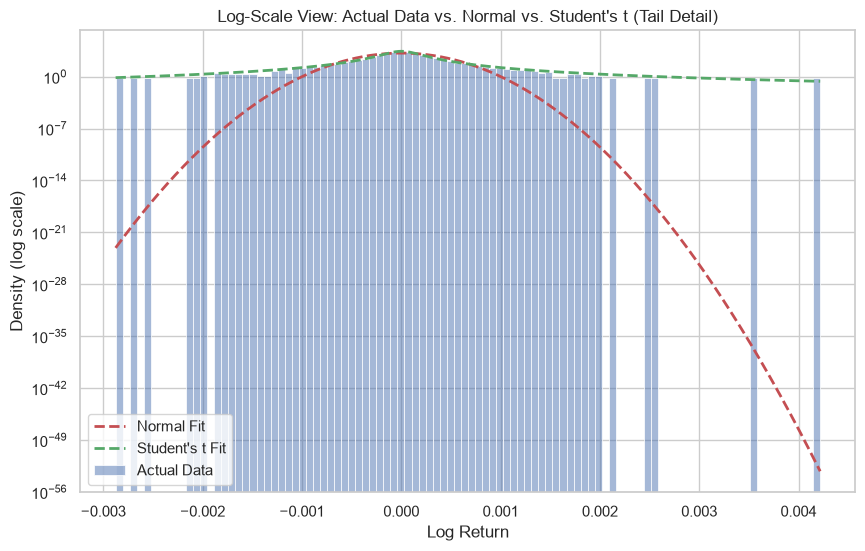

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(clean_returns, bins=100, stat='density', label='Actual Data', alpha=0.5)
plt.plot(x, stats.norm.pdf(x, *norm_params), 'r--', label='Normal Fit', linewidth=2)
plt.plot(x, stats.t.pdf(x, *t_params), 'g--', label="Student's t Fit", linewidth=2)

plt.yscale('log')
plt.title("Log-Scale View: Actual Data vs. Normal vs. Student's t (Tail Detail)")
plt.xlabel("Log Return")
plt.ylabel("Density (log scale)")
plt.legend()
plt.show()

In [ ]:
norm_loglik = np.sum(stats.norm.logpdf(clean_returns, *norm_params))
t_loglik = np.sum(stats.t.logpdf(clean_returns, *t_params))


norm_aic = 2*2-2 * norm_loglik
t_aic = 2*3-2*t_loglik 

print(f"Normal AIC: {norm_aic:.2f}")
print(f"Student's t  AIC: {t_aic:.2f}")

Normal AIC: -288547.84
Student's t  AIC: -296136.99


In [ ]:
from 